# periodograms.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lombscargle
import antares_client

In [2]:
t = 100 * np.random.random(1000) # irregular time spacings
y = np.sin(2*np.pi*t) # perfect signal, period = 1, omega = 2*pi
dy = 3*np.random.randn(1000) # add noise, homoscedastic errors (astropy lombscargle handles heteroscedastic errors)
y += dy
w = np.linspace(0.25,10,1000) # array of frequencies
power = lombscargle(t,y,w, normalize=False)

Text(0, 0.5, '$y(t)$')

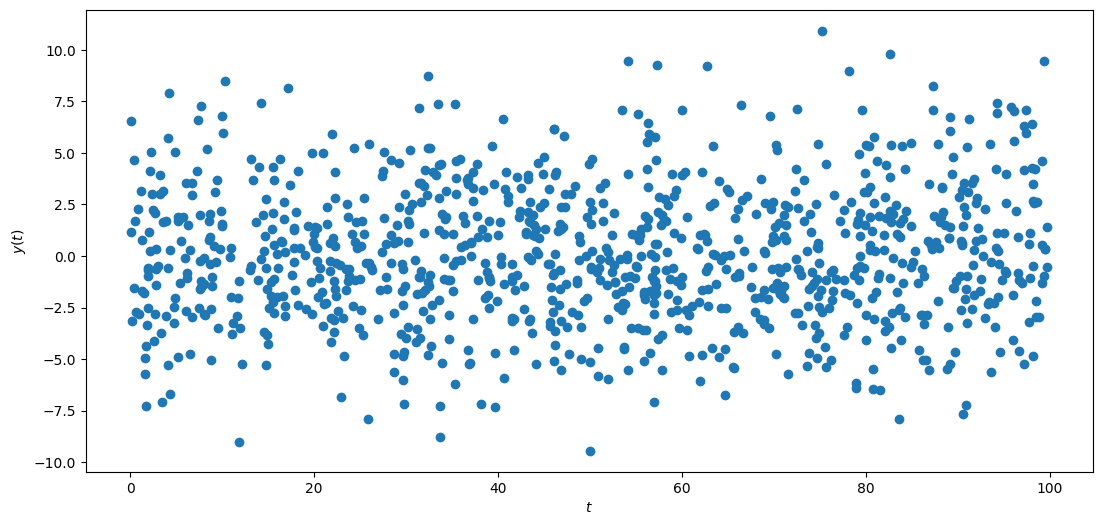

In [3]:
fig1 = plt.figure(figsize=(13,6))
plt.plot(t,y,'o')
plt.xlabel('$t$')
plt.ylabel('$y(t)$')

Text(0, 0.5, '$P(\\omega)$')

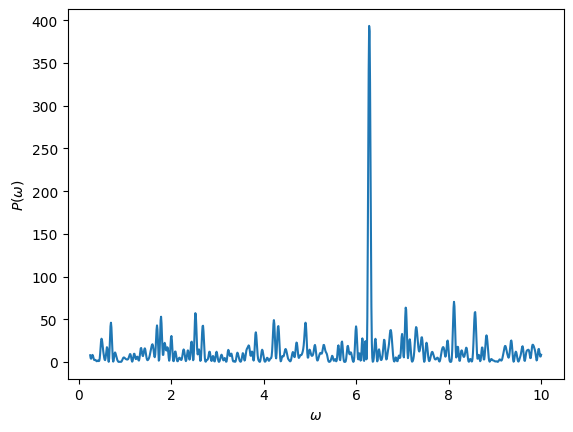

In [4]:
fig2 = plt.figure()
plt.plot(w, power, '-')
plt.xlabel('$\omega$')
plt.ylabel('$P(\omega)$')

Now fetch a variable object (LPV) from Antares/ZTF :

In [5]:
#locus = antares_client.search.get_by_ztf_object_id("ZTF18aapmlzb")
locus = antares_client.search.get_by_id("ANT2018fbth4") # https://antares.noirlab.edu/loci/ANT2018fbth4
df = locus.timeseries.to_pandas()
df

,ztf_jd,ztf_fid,ztf_pid,ztf_diffmaglim,ztf_pdiffimfilename,ztf_programpi,ztf_programid,ztf_candid,ztf_isdiffpos,ztf_tblid,...,ztf_clrmed,ztf_clrrms,ztf_neargaia,ztf_neargaiabright,ztf_maggaia,ztf_maggaiabright,ztf_exptime,ztf_drb,ztf_drbversion,ztf_object_id
time,,,,,,,,,,,,,,,,,,,,,
2018-08-07 12:02:46.000307,2.458338e+06,2,583501921415,19.432199,/ztf/archive/sci/2018/0807/501736/ztf_20180807...,Kulkarni,1,583501921415015040,t,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-13 11:43:22.002235,2.458344e+06,2,589488445715,20.341999,/ztf/archive/sci/2018/0813/488426/ztf_20180813...,Kulkarni,1,589488445715015040,t,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-13 11:44:01.003190,2.458344e+06,2,589488901415,20.356400,/ztf/archive/sci/2018/0813/488900/ztf_20180813...,Kulkarni,1,<NA>,NaN,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-14 11:24:21.997434,2.458345e+06,2,590475255715,20.243999,/ztf/archive/sci/2018/0814/475255/ztf_20180814...,Kulkarni,1,590475255715015040,t,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-15 11:50:50.997104,2.458346e+06,2,591493645715,20.456600,/ztf/archive/sci/2018/0815/493623/ztf_20180815...,Kulkarni,1,591493645715015040,t,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01 04:45:24.998403,2.461101e+06,2,3346198205715,19.757401,/ztf/archive/sci/2026/0301/198137/ztf_20260301...,Kasliwal/Graham,1,3346198205715010048,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZTF18aabqtud
2026-03-01 05:42:59.002561,2.461101e+06,1,3346238185715,19.446125,ztf_20260301238183_000659_zg_c15_o_q2_scimrefd...,Kasliwal/Graham,1,3346238185715010048,f,0,...,0.904,0.233870,10.831628,36.031628,18.638332,13.030558,30.0,0.999909,d6_m7,ZTF18aabqtud
2026-03-02 04:19:55.001270,2.461102e+06,3,3347180495715,19.554600,/ztf/archive/sci/2026/0302/180382/ztf_20260302...,Kasliwal/Graham,1,<NA>,NaN,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZTF18aabqtud


In [6]:
df = df[['ant_mjd', 'ztf_fid', 'ztf_magpsf', 'ztf_sigmapsf']]
dn = df.dropna()
dn

,ant_mjd,ztf_fid,ztf_magpsf,ztf_sigmapsf
time,,,,
2018-08-07 12:02:46.000307,58337.501921,2,13.703900,0.023258
2018-08-13 11:43:22.002235,58343.488449,2,13.633500,0.026188
2018-08-14 11:24:21.997434,58344.475255,2,13.650600,0.016859
2018-08-15 11:50:50.997104,58345.493646,2,13.614200,0.023643
2018-08-17 10:44:59.000636,58347.447905,2,13.666699,0.023166
...,...,...,...,...
2026-02-28 05:40:13.002254,61099.236262,1,16.776236,0.053837
2026-03-01 04:45:24.998403,61100.198206,2,19.639200,0.222218
2026-03-01 05:42:59.002561,61100.238183,1,16.771189,0.067444


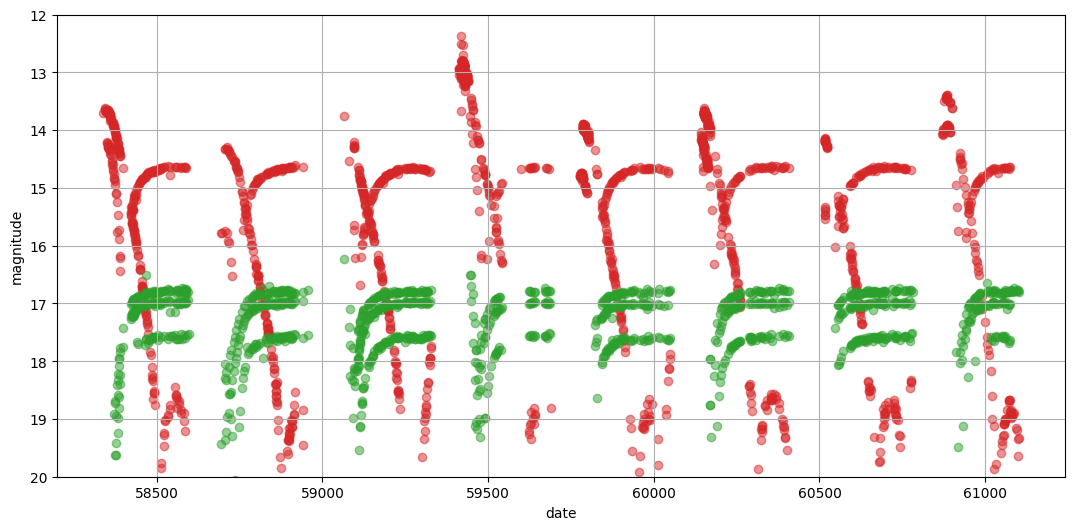

In [7]:
fig3 = plt.figure(figsize=(13,6))
tg = dn['ant_mjd'][dn['ztf_fid']==1] # times for green filter
tr = dn['ant_mjd'][dn['ztf_fid']==2] # times for red filter
mg = dn['ztf_magpsf'][dn['ztf_fid']==1] # magnitudes for green filter
mr = dn['ztf_magpsf'][dn['ztf_fid']==2] # magnitudes for red filter
plt.scatter(tr, mr, c='C3', alpha=0.5)
plt.scatter(tg, mg, c='C2', alpha=0.5)
plt.ylim(20,12)
plt.xlabel('date')
plt.ylabel('magnitude')
plt.grid()

In [8]:
w2 = np.linspace(0.005,0.1,5000) # array of frequencies
powerg = lombscargle(tg,mg,w2, normalize=False)
powerr = lombscargle(tr,mr,w2, normalize=False)

Think about the periods of the peaks below...

Text(0, 0.5, '$P(\\omega)$')

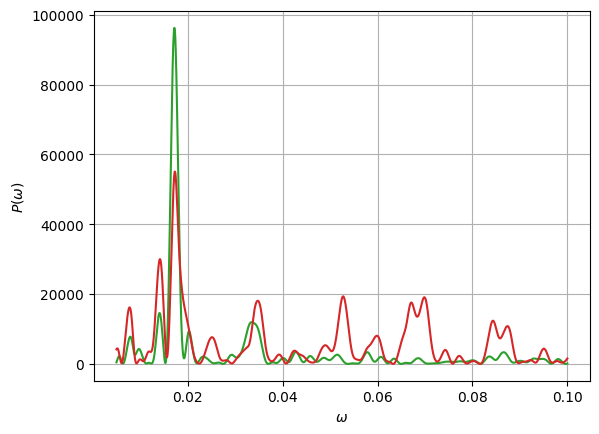

In [9]:
fig4 = plt.figure()
plt.plot(w2, powerg, '-', c='C2')
plt.plot(w2, powerr, '-', c='C3')
plt.grid()
plt.xlabel('$\omega$')
plt.ylabel('$P(\omega)$')

In [10]:
P = 2*np.pi/w2 # period

(0.0, 500.0)

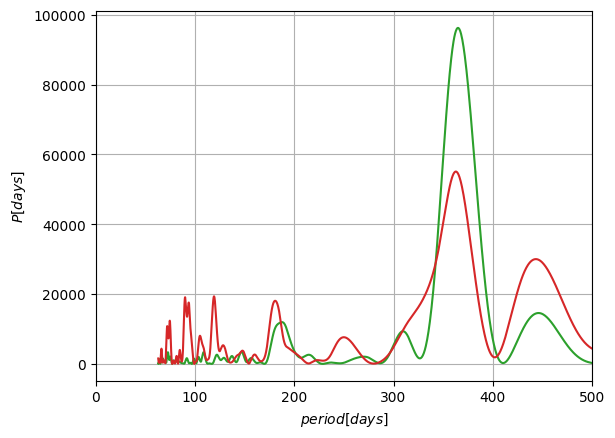

In [11]:
fig5 = plt.figure()
plt.plot(P, powerg, '-', c='C2')
plt.plot(P, powerr, '-', c='C3')
plt.grid()
plt.xlabel('$period [days]$')
plt.ylabel('$P[days]$')
plt.xlim(0,500)

Next, RR Lyra star in Virgo  
https://antares.noirlab.edu/loci/ANT20192jrs2

In [12]:
locus = antares_client.search.get_by_id("ANT20192jrs2") 
df = locus.timeseries.to_pandas()
df = df[['ant_mjd', 'ztf_fid', 'ztf_magpsf', 'ztf_sigmapsf']]
dn = df.dropna()

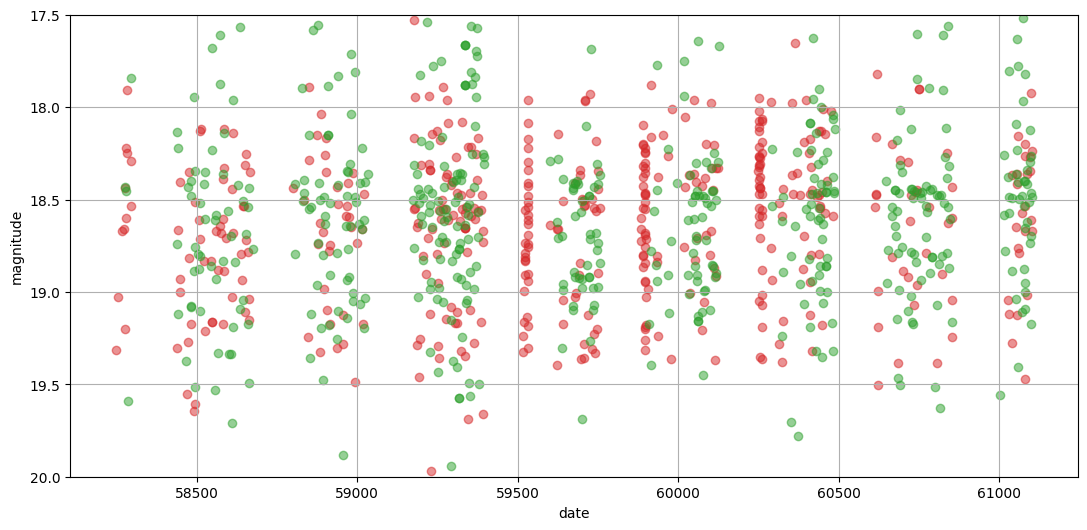

In [13]:
fig6 = plt.figure(figsize=(13,6))
tg = dn['ant_mjd'][dn['ztf_fid']==1] # times for green filter
tr = dn['ant_mjd'][dn['ztf_fid']==2] # times for red filter
mg = dn['ztf_magpsf'][dn['ztf_fid']==1] # magnitudes for green filter
mr = dn['ztf_magpsf'][dn['ztf_fid']==2] # magnitudes for red filter
plt.scatter(tr, mr, c='C3', alpha=0.5)
plt.scatter(tg, mg, c='C2', alpha=0.5)
plt.ylim(20,17.5)
plt.xlabel('date')
plt.ylabel('magnitude')
plt.grid()

In [14]:
powerg = lombscargle(tg,mg,w2, normalize=False)
powerr = lombscargle(tr,mr,w2, normalize=False)

Text(0, 0.5, '$P(\\omega)$')

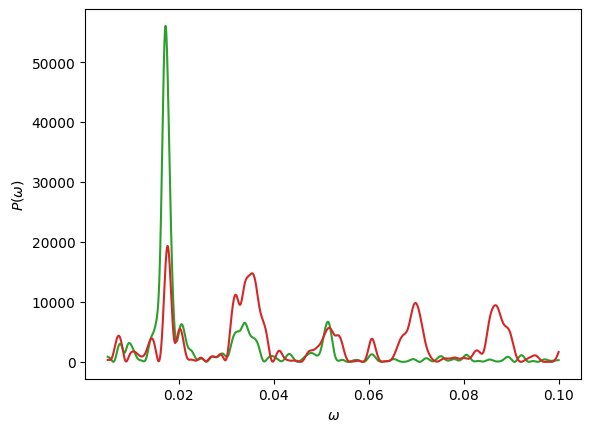

In [15]:
fig6 = plt.figure()
plt.plot(w2, powerg, '-', c='C2')
plt.plot(w2, powerr, '-', c='C3')
plt.xlabel('$\omega$')
plt.ylabel('$P(\omega)$')

Next, RS Canum Venaticorum variable star:  
https://antares.noirlab.edu/loci/ANT2020l2ta

In [16]:
locus = antares_client.search.get_by_id("ANT2020l2ta") 
df = locus.timeseries.to_pandas()
df = df[['ant_mjd', 'ztf_fid', 'ztf_magpsf', 'ztf_sigmapsf']]
dn = df.dropna()

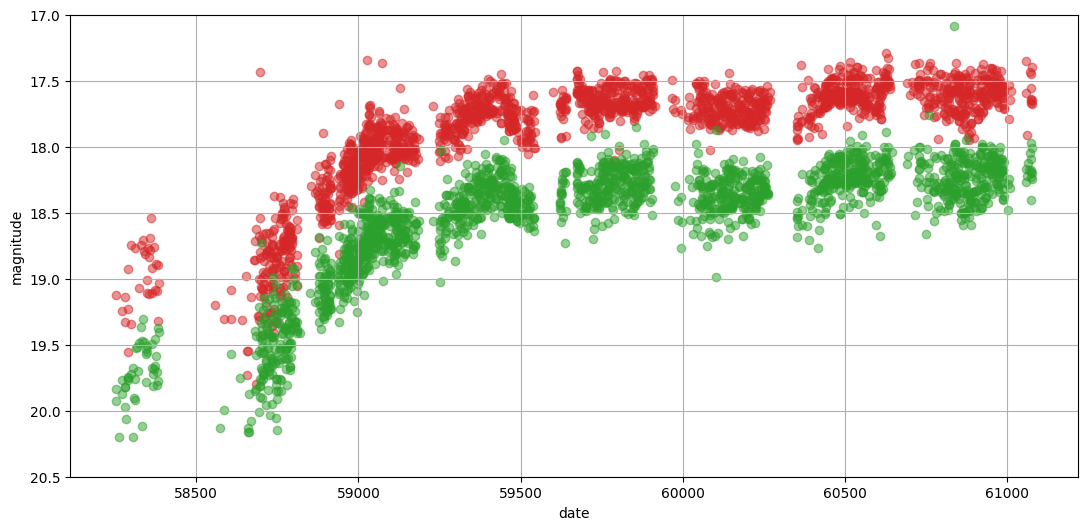

In [17]:
fig7 = plt.figure(figsize=(13,6))
tg = dn['ant_mjd'][dn['ztf_fid']==1] # times for green filter
tr = dn['ant_mjd'][dn['ztf_fid']==2] # times for red filter
mg = dn['ztf_magpsf'][dn['ztf_fid']==1] # magnitudes for green filter
mr = dn['ztf_magpsf'][dn['ztf_fid']==2] # magnitudes for red filter
plt.scatter(tr, mr, c='C3', alpha=0.5)
plt.scatter(tg, mg, c='C2', alpha=0.5)
plt.ylim(20.5,17)
plt.xlabel('date')
plt.ylabel('magnitude')
plt.grid()

In [18]:
powerg = lombscargle(tg,mg,w2, normalize=False)
powerr = lombscargle(tr,mr,w2, normalize=False)

Text(0, 0.5, '$P(\\omega)$')

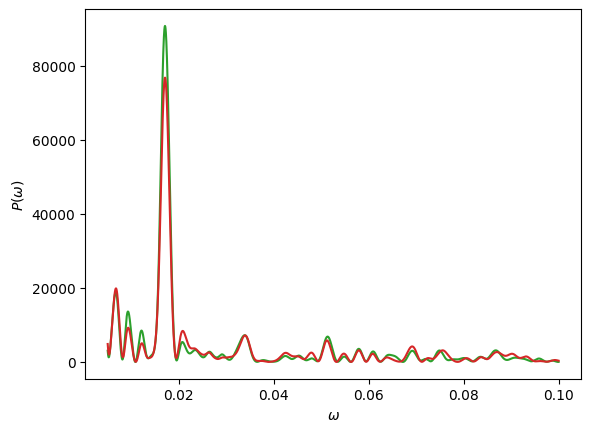

In [19]:
fig8 = plt.figure()
plt.plot(w2, powerg, '-', c='C2')
plt.plot(w2, powerr, '-', c='C3')
plt.xlabel('$\omega$')
plt.ylabel('$P(\omega)$')

Next, AGN in Virgo:  
https://antares.noirlab.edu/loci/ANT2019s73eo

In [20]:
locus = antares_client.search.get_by_id("ANT2019s73eo") 
df = locus.timeseries.to_pandas()
df = df[['ant_mjd', 'ztf_fid', 'ztf_magpsf', 'ztf_sigmapsf']]
dn = df.dropna()

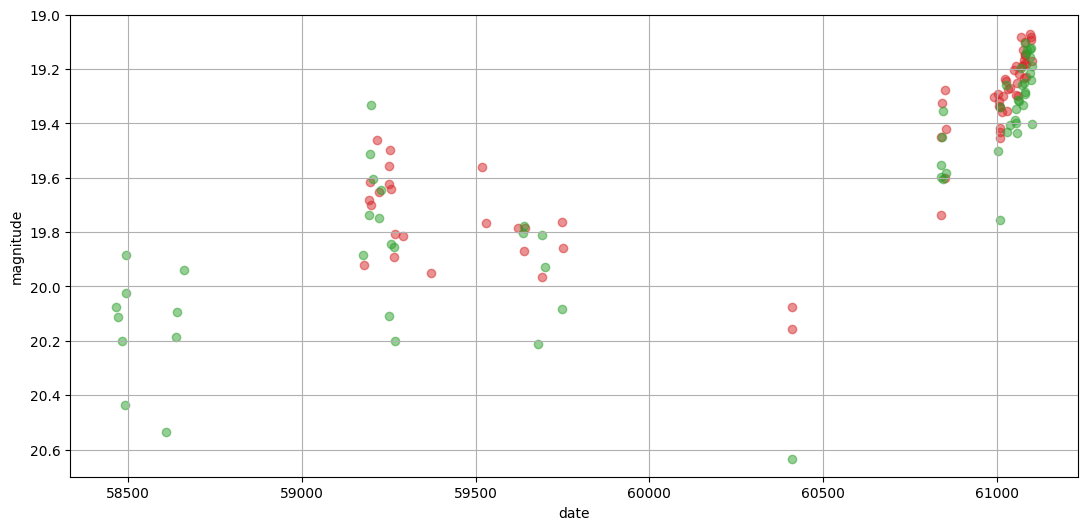

In [21]:
fig9 = plt.figure(figsize=(13,6))
tg = dn['ant_mjd'][dn['ztf_fid']==1] # times for green filter
tr = dn['ant_mjd'][dn['ztf_fid']==2] # times for red filter
mg = dn['ztf_magpsf'][dn['ztf_fid']==1] # magnitudes for green filter
mr = dn['ztf_magpsf'][dn['ztf_fid']==2] # magnitudes for red filter
plt.scatter(tr, mr, c='C3', alpha=0.5)
plt.scatter(tg, mg, c='C2', alpha=0.5)
plt.ylim(20.7,19.0)
plt.xlabel('date')
plt.ylabel('magnitude')
plt.grid()

In [22]:
w3 = np.logspace(-2,2,1000) # note AGN with BH mass of 10^8 MSun has omega_break ~ 1 (in days)
powerg = lombscargle(tg,mg,w3, normalize=False)
powerr = lombscargle(tr,mr,w3, normalize=False)

Text(0, 0.5, '$P(\\omega)$')

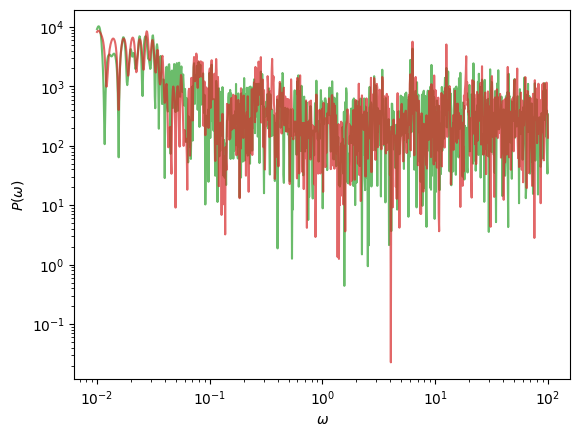

In [23]:
fig10 = plt.figure()
plt.plot(w3, powerg, '-', alpha=0.7, c='C2')
plt.plot(w3, powerr, '-', alpha=0.7, c='C3')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\omega$')
plt.ylabel('$P(\omega)$')